In [7]:
PROJECT_ROOT = "../sequence_to_svm_minimal"

# For amp/decoy length test
AMP_PATH = f"{PROJECT_ROOT}/data/gnn_training_dataset/normalized_combined_set/amps.fasta"
DECOY_PATH = f"{PROJECT_ROOT}/data/gnn_training_dataset/normalized_combined_set/decoys.fasta"

# For AA counts
TRAIN_CSV = f"{PROJECT_ROOT}/data/gnn_training_dataset/normalized_combined_set/generated/geometric_features.csv"
TEST_CSV = f"{PROJECT_ROOT}/data/test/PDDP_candidates/generated/geometric_features.csv"

TRAIN_PDB = f"{PROJECT_ROOT}/data/gnn_training_dataset/normalized_combined_set/generated/structures"
TEST_PDB = f"{PROJECT_ROOT}/data/test/PDDP_candidates/generated/structures"


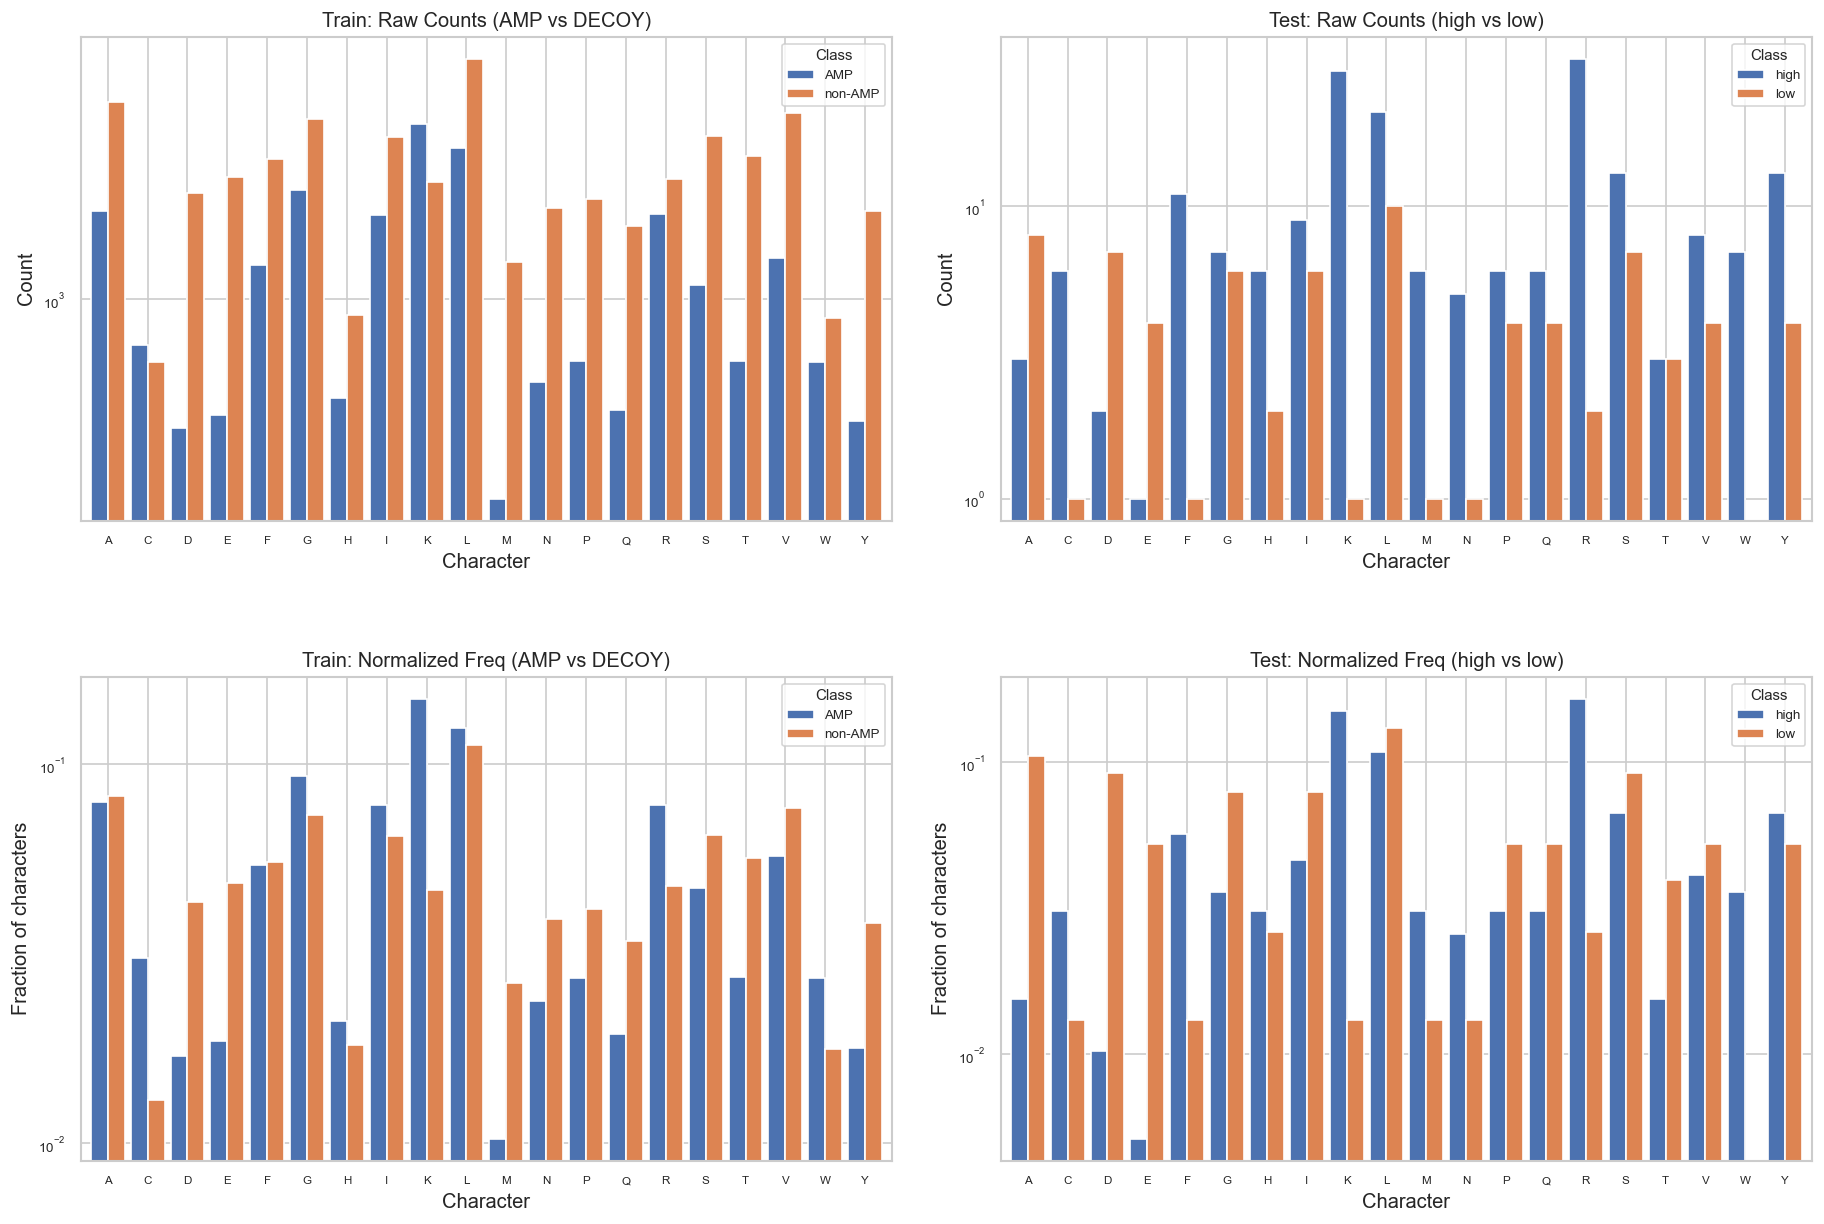

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

TRAIN_GEOM_CSV = Path(TRAIN_CSV)
TEST_GEOM_CSV = Path(TEST_CSV)

STANDARD_AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")


def _char_counts(seqs: pd.Series) -> pd.Series:
    seqs = seqs.dropna().astype(str)
    c = Counter()
    for s in seqs:
        c.update(s)
    return pd.Series(dict(c), dtype=int)


def _plot_order(keys: list[str]) -> list[str]:
    key_set = set(keys)
    extras = sorted(k for k in key_set if k not in STANDARD_AA_ORDER)
    return [k for k in STANDARD_AA_ORDER if k in key_set] + extras


def _split_amp_nonamp(
    df: pd.DataFrame,
    *,
    split_pred_col: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, str, str]:
    peptide_ids = df["peptide_id"].astype(str)
    has_amp_id = peptide_ids.str.startswith("AMP_").any()
    has_decoy_id = peptide_ids.str.startswith("DECOY_").any()

    if split_pred_col is not None:
        if split_pred_col not in df.columns:
            raise ValueError(
                f"Requested split_pred_col={split_pred_col!r} not found. Available columns: {list(df.columns)}"
            )
        amp_df = df[df[split_pred_col] == 1]
        non_amp_df = df[df[split_pred_col] == 0]
        return amp_df, non_amp_df, "AMP", "non-AMP"

    if has_amp_id or has_decoy_id:
        amp_df = df[peptide_ids.str.startswith("AMP_")]
        non_amp_df = df[peptide_ids.str.startswith("DECOY_")]
        return amp_df, non_amp_df, "AMP", "non-AMP"

    has_high = peptide_ids.str.startswith("high_").any()
    has_low = peptide_ids.str.startswith("low_").any()
    if has_high and has_low:
        amp_df = df[peptide_ids.str.startswith("high_")]
        non_amp_df = df[peptide_ids.str.startswith("low_")]
        return amp_df, non_amp_df, "high", "low"

    if "label" in df.columns and set(df["label"].dropna().unique()) >= {0, 1}:
        amp_df = df[df["label"] == 1]
        non_amp_df = df[df["label"] == 0]
        return amp_df, non_amp_df, "AMP", "non-AMP"

    raise ValueError(
        "No way to split into two classes. Use split_pred_col=..., or AMP_/DECOY_ ids, "
        "or high_/low_ peptide_id prefixes, or a binary label column (0/1)."
    )


def _counts_df(amp_df: pd.DataFrame, non_amp_df: pd.DataFrame, amp_label: str, non_amp_label: str) -> pd.DataFrame:
    amp_counts = _char_counts(amp_df["sequence"])
    non_amp_counts = _char_counts(non_amp_df["sequence"])
    plot_df = pd.DataFrame({amp_label: amp_counts, non_amp_label: non_amp_counts}).fillna(0)
    order = _plot_order(list(plot_df.index))
    return plot_df.loc[order]


def _plot_counts(
    ax: plt.Axes,
    plot_df: pd.DataFrame,
    *,
    title: str,
    ylabel: str,
) -> None:
    plot_df.plot(kind="bar", width=0.85, ax=ax)
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel("Character")
    ax.set_ylabel(ylabel)
    ax.legend(title="Class", fontsize=8, title_fontsize=9)
    ax.tick_params(axis="x", labelrotation=0, labelsize=7)
    ax.tick_params(axis="y", labelsize=8)


def _plot_from_csv(
    csv_path: Path,
    *,
    split_pred_col: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, str, str, pd.DataFrame]:
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing file: {csv_path}")

    df = pd.read_csv(csv_path)
    if "peptide_id" not in df.columns or "sequence" not in df.columns:
        raise ValueError(f"Expected columns peptide_id and sequence in {csv_path}. Available columns: {list(df.columns)}")

    amp_df, non_amp_df, amp_label, non_amp_label = _split_amp_nonamp(df, split_pred_col=split_pred_col)
    if amp_df.empty or non_amp_df.empty:
        raise ValueError(
            f"Cannot plot split for {csv_path}: need both classes, got amp_rows={len(amp_df)} non_amp_rows={len(non_amp_df)}"
        )

    counts = _counts_df(amp_df, non_amp_df, amp_label, non_amp_label)
    return amp_df, non_amp_df, amp_label, non_amp_label, counts


# 2x2 grid: raw counts vs normalized by class size
fig, axes = plt.subplots(2, 2, figsize=(16, 11), dpi=120, sharex=False)
(ax_train_raw, ax_test_raw), (ax_train_norm, ax_test_norm) = axes

_, _, amp_label_tr, non_amp_label_tr, train_counts = _plot_from_csv(TRAIN_GEOM_CSV)
_plot_counts(
    ax_train_raw,
    train_counts,
    title="Train: Raw Counts (AMP vs DECOY)",
    ylabel="Count",
)

# Normalize by total characters per class
train_norm = train_counts.div(train_counts.sum(axis=0), axis=1)
_plot_counts(
    ax_train_norm,
    train_norm,
    title="Train: Normalized Freq (AMP vs DECOY)",
    ylabel="Fraction of characters",
)

test_csv_path = TEST_GEOM_CSV
if not test_csv_path.exists():
    _alt_test = Path(PROJECT_ROOT) / "data/test/initial_set/geometric_features.csv"
    if _alt_test.exists():
        print(f"Note: {test_csv_path} not found; test AA-count panels use {_alt_test}")
        test_csv_path = _alt_test

_, _, amp_label_te, non_amp_label_te, test_counts = _plot_from_csv(test_csv_path)
_plot_counts(
    ax_test_raw,
    test_counts,
    title=f"Test: Raw Counts ({amp_label_te} vs {non_amp_label_te})",
    ylabel="Count",
)

test_norm = test_counts.div(test_counts.sum(axis=0), axis=1)
_plot_counts(
    ax_test_norm,
    test_norm,
    title=f"Test: Normalized Freq ({amp_label_te} vs {non_amp_label_te})",
    ylabel="Fraction of characters",
)

plt.tight_layout(pad=3.0, h_pad=4.0, w_pad=2.0)
plt.show()


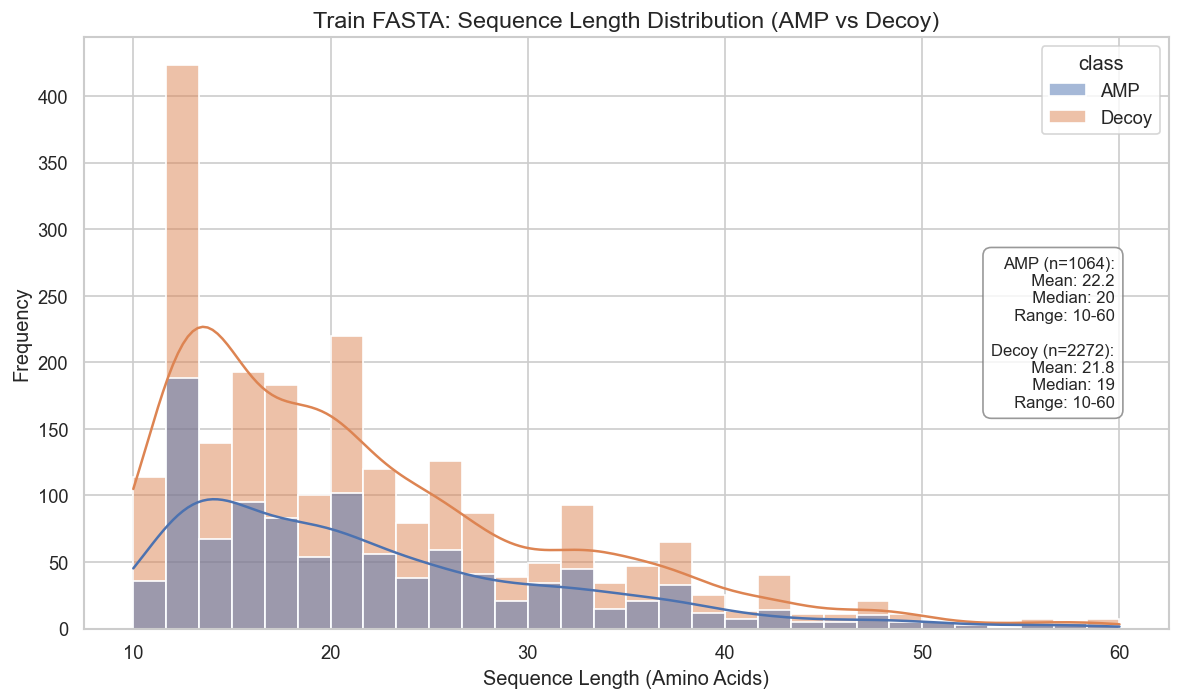

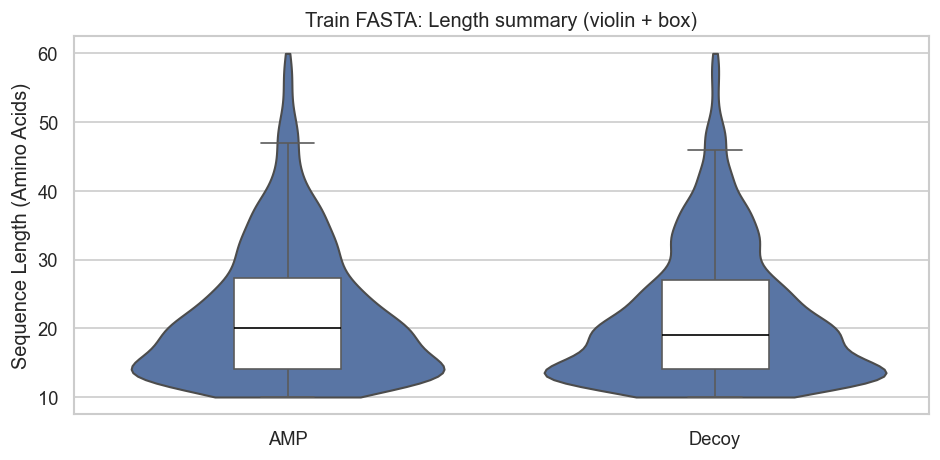

In [9]:
# Peptide length analysis (FASTA baseline): Train AMP vs Decoy
# Ported from: sequence_to_svm_minimal/scripts/data_evaluation/analyze_fasta_lengths.py

import seaborn as sns

AMP_FASTA = Path(AMP_PATH)
DECOY_FASTA = Path(DECOY_PATH)


def parse_fasta_lengths(fasta_path: Path) -> list[int]:
    """Parse a FASTA file and return a list of sequence lengths."""
    lengths: list[int] = []
    current_len = 0
    with open(fasta_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if current_len > 0:
                    lengths.append(current_len)
                    current_len = 0
            else:
                current_len += len(line.replace(" ", "").replace("\n", ""))

        if current_len > 0:
            lengths.append(current_len)

    return lengths


if not AMP_FASTA.exists():
    raise FileNotFoundError(f"Missing AMP FASTA: {AMP_FASTA}")
if not DECOY_FASTA.exists():
    raise FileNotFoundError(f"Missing decoy FASTA: {DECOY_FASTA}")

amp_lengths = parse_fasta_lengths(AMP_FASTA)
decoy_lengths = parse_fasta_lengths(DECOY_FASTA)

plot_df = pd.DataFrame(
    {
        "class": ["AMP"] * len(amp_lengths) + ["Decoy"] * len(decoy_lengths),
        "length": amp_lengths + decoy_lengths,
    }
)

summary = (
    plot_df.groupby("class")["length"]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .sort_index()
)
summary

sns.set_theme(style="whitegrid")

# Plot 1: Histogram + KDE
plt.figure(figsize=(10, 6), dpi=120)

sns.histplot(
    data=plot_df,
    x="length",
    hue="class",
    kde=True,
    alpha=0.5,
    bins=30,
)

plt.title("Train FASTA: Sequence Length Distribution (AMP vs Decoy)", fontsize=14)
plt.xlabel("Sequence Length (Amino Acids)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

stats_lines = []
for cls in ["AMP", "Decoy"]:
    lengths = plot_df.loc[plot_df["class"] == cls, "length"].tolist()
    if not lengths:
        continue
    lengths_sorted = sorted(lengths)
    median = lengths_sorted[len(lengths_sorted) // 2]
    stats_lines.append(
        f"{cls} (n={len(lengths)}):\n"
        f"  Mean: {sum(lengths) / len(lengths):.1f}\n"
        f"  Median: {median}\n"
        f"  Range: {min(lengths)}-{max(lengths)}"
    )

plt.annotate(
    "\n\n".join(stats_lines),
    xy=(0.95, 0.5),
    xycoords="axes fraction",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8),
    ha="right",
    va="center",
)

plt.tight_layout()
plt.show()

# Plot 2: Violin + box summary
plt.figure(figsize=(8, 4), dpi=120)

sns.violinplot(
    data=plot_df,
    x="class",
    y="length",
    inner=None,
    cut=0,
)

sns.boxplot(
    data=plot_df,
    x="class",
    y="length",
    width=0.25,
    showcaps=True,
    boxprops={"facecolor": "white", "zorder": 3},
    showfliers=False,
    whiskerprops={"zorder": 3},
    medianprops={"color": "black", "zorder": 4},
    zorder=3,
)

plt.title("Train FASTA: Length summary (violin + box)")
plt.xlabel("")
plt.ylabel("Sequence Length (Amino Acids)")
plt.tight_layout()
plt.show()


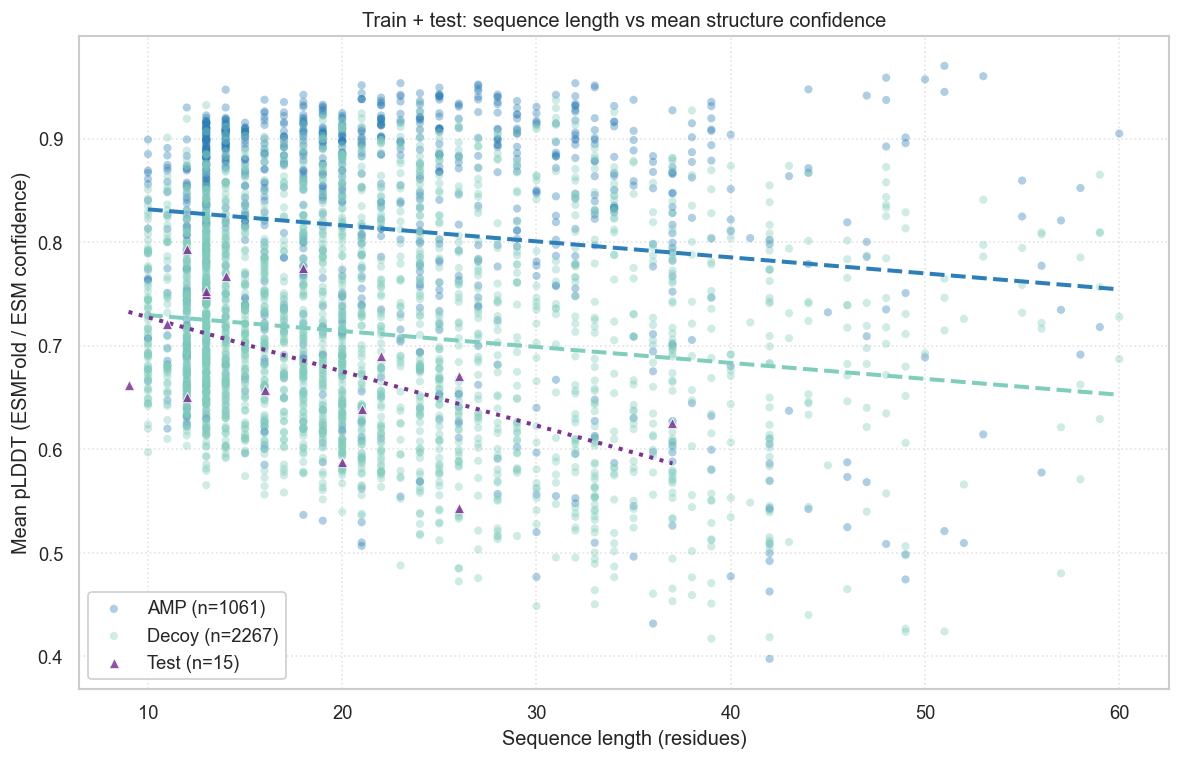

Pearson r(length, mean pLDDT), all training rows: -0.1247
Pearson r(length, mean pLDDT), test rows (geometric_features.csv): -0.5370


In [10]:
# Train + test CSV: sequence length vs mean ESMFold pLDDT (B-factor confidence, typically 0–1)
import numpy as np

train_geom = pd.read_csv(TRAIN_GEOM_CSV)
need = {"length", "plddt_mean", "label"}
if not need <= set(train_geom.columns):
    raise ValueError(f"Expected columns {sorted(need)} in {TRAIN_GEOM_CSV}; got {list(train_geom.columns)}")

train_geom = train_geom.assign(
    class_=np.where(train_geom["label"] == 1, "AMP", "Decoy"),
)

test_path = TEST_GEOM_CSV
if not test_path.exists():
    _fb = Path(PROJECT_ROOT) / "data/test/initial_set/geometric_features.csv"
    if _fb.exists():
        print(f"Note: {test_path} not found; overlay uses fallback {_fb}")
        test_path = _fb

test_geom = None
if test_path.exists():
    test_geom = pd.read_csv(test_path)
    tneed = {"length", "plddt_mean"}
    if not tneed <= set(test_geom.columns):
        raise ValueError(f"Expected columns {sorted(tneed)} in {test_path}; got {list(test_geom.columns)}")
else:
    print(f"Warning: test geometric_features not found at {TEST_GEOM_CSV}; skipping test overlay.")

fig, ax = plt.subplots(figsize=(10, 6.5), dpi=120)
ax.grid(True, linestyle=":", alpha=0.55)
ax.set_axisbelow(True)

colors = {"AMP": "#2c7fb8", "Decoy": "#7fcdbb", "Test": "#7b3294"}
for cls in ["AMP", "Decoy"]:
    sub = train_geom.loc[train_geom["class_"] == cls]
    ax.scatter(
        sub["length"],
        sub["plddt_mean"],
        c=colors[cls],
        alpha=0.38,
        s=24,
        label=f"{cls} (n={len(sub)})",
        edgecolors="none",
    )
    if len(sub) >= 2:
        x = sub["length"].to_numpy(dtype=float)
        y = sub["plddt_mean"].to_numpy(dtype=float)
        coef = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 80)
        ax.plot(xs, np.poly1d(coef)(xs), color=colors[cls], lw=2.4, linestyle="--")

if test_geom is not None:
    ax.scatter(
        test_geom["length"],
        test_geom["plddt_mean"],
        c=colors["Test"],
        alpha=0.85,
        s=38,
        marker="^",
        edgecolors="white",
        linewidths=0.6,
        label=f"Test (n={len(test_geom)})",
        zorder=5,
    )
    if len(test_geom) >= 2:
        x = test_geom["length"].to_numpy(dtype=float)
        y = test_geom["plddt_mean"].to_numpy(dtype=float)
        coef = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 80)
        ax.plot(xs, np.poly1d(coef)(xs), color=colors["Test"], lw=2.4, linestyle=":", zorder=4)

ax.set_xlabel("Sequence length (residues)")
ax.set_ylabel("Mean pLDDT (ESMFold / ESM confidence)")
ax.set_title("Train + test: sequence length vs mean structure confidence")
ax.legend(loc="best", framealpha=0.95)
plt.tight_layout()
plt.show()

r_all = train_geom["length"].corr(train_geom["plddt_mean"])
print(f"Pearson r(length, mean pLDDT), all training rows: {r_all:.4f}")
if test_geom is not None and len(test_geom) >= 2:
    r_te = test_geom["length"].corr(test_geom["plddt_mean"])
    print(f"Pearson r(length, mean pLDDT), test rows ({test_path.name}): {r_te:.4f}")


C:\Users\bioin\AppData\Local\Temp\ipykernel_10580\3096414196.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\bioin\AppData\Local\Temp\ipykernel_10580\3096414196.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


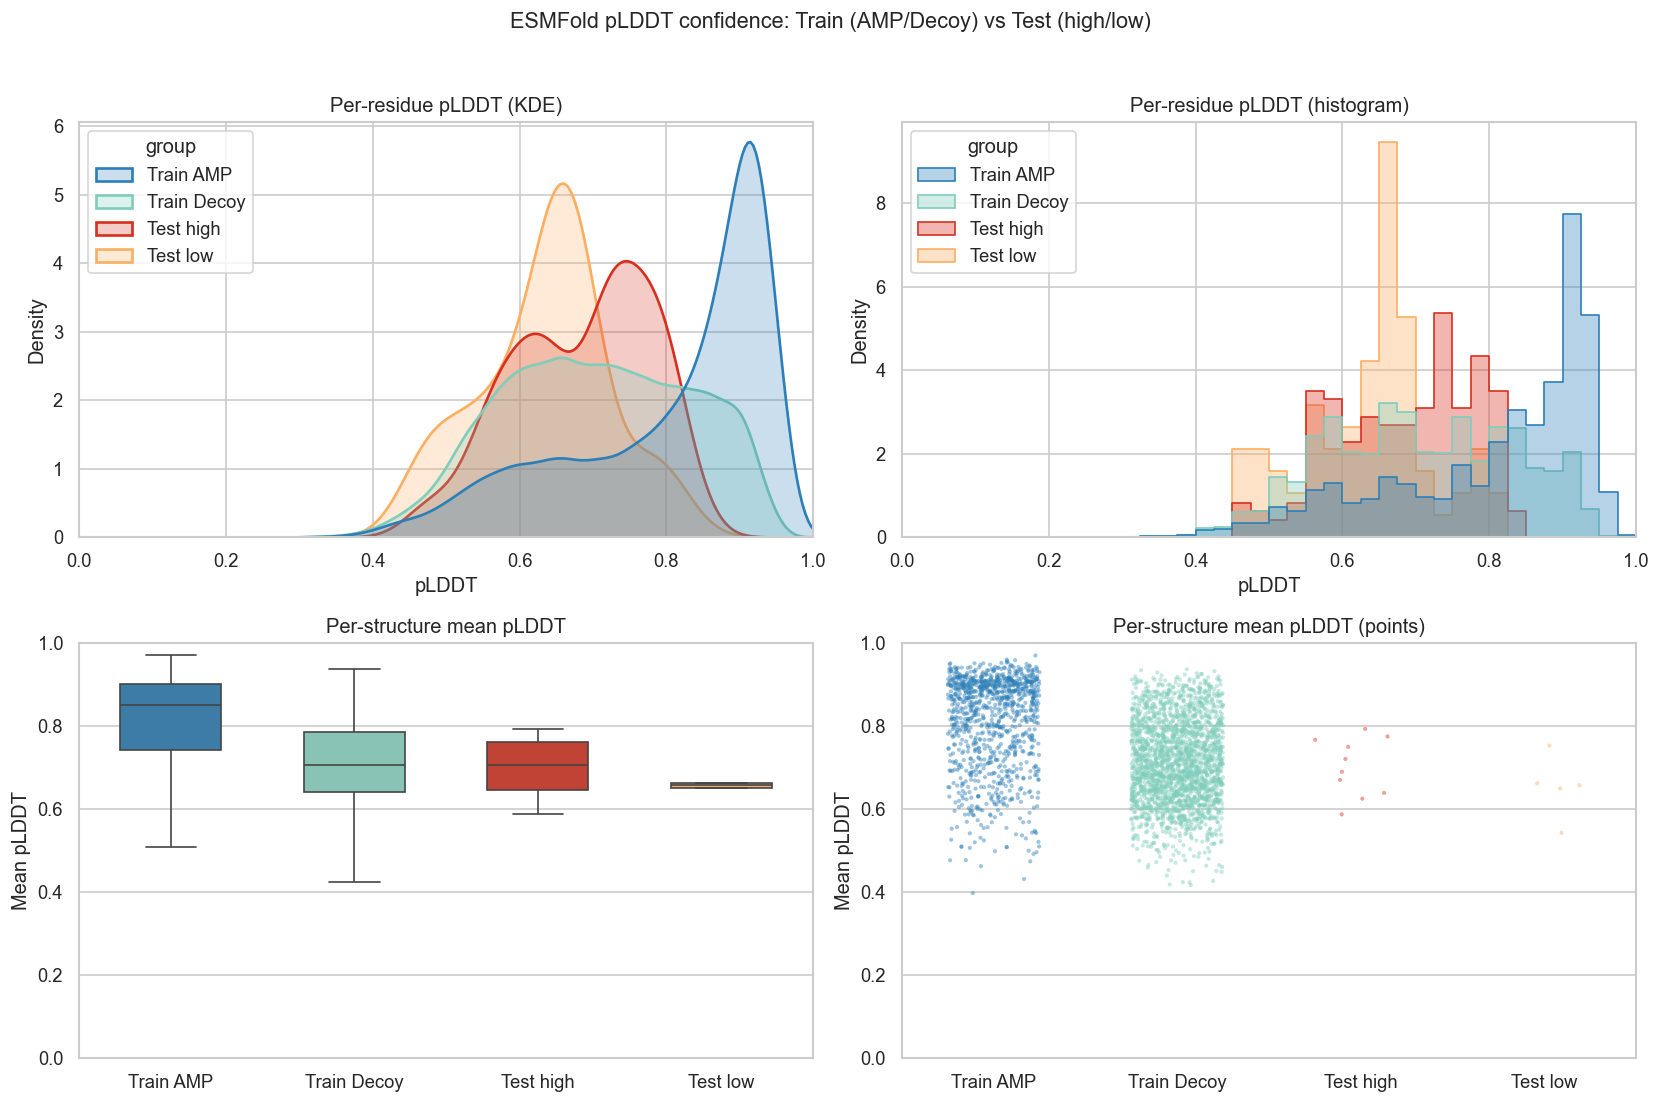

,count,mean,std,min,5%,50%,95%,max,n_residues
group,,,,,,,,,
Train AMP,1061.0,0.813,0.111,0.398,0.597,0.852,0.933,0.970,23547
Train Decoy,2267.0,0.711,0.099,0.417,0.555,0.707,0.879,0.937,49364
Test high,10.0,0.702,0.070,0.588,0.604,0.705,0.785,0.793,194
Test low,5.0,0.653,0.075,0.543,0.564,0.658,0.735,0.753,76


In [11]:
# pLDDT confidence (per-residue + per-structure) across train/test PDB groups.
# Uses TRAIN_PDB / TEST_PDB globals from the first cell.
import numpy as np

GROUP_COLORS = {
    "Train AMP": "#2c7fb8",
    "Train Decoy": "#7fcdbb",
    "Test high": "#d7301f",
    "Test low": "#fdae61",
}


def _ca_plddt(pdb_path: Path) -> np.ndarray:
    vals: list[float] = []
    with open(pdb_path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.startswith("ATOM") or line[12:16].strip() != "CA":
                continue
            try:
                vals.append(float(line[60:66]))
            except ValueError:
                pass
    return np.asarray(vals, dtype=float)


def _collect_group(label: str, pdb_paths: list[Path]) -> pd.DataFrame:
    rows: list[dict] = []
    for p in pdb_paths:
        v = _ca_plddt(p)
        if v.size == 0:
            continue
        rows.append({"group": label, "file": p.name, "n_res": v.size, "mean_plddt": v.mean(), "residues": v})
    return pd.DataFrame(rows)


def _explode_residues(per_struct: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "group": np.repeat(per_struct["group"].values, per_struct["n_res"].values),
            "plddt": np.concatenate(per_struct["residues"].values),
        }
    )


train_groups: dict[str, list[Path]] = {
    "Train AMP": sorted((Path(TRAIN_PDB) / "AMP").glob("*.pdb")),
    "Train Decoy": sorted((Path(TRAIN_PDB) / "DECOY").glob("*.pdb")),
}
test_seq_dir = Path(TEST_PDB) / "sequences"
test_groups: dict[str, list[Path]] = {
    "Test high": sorted(test_seq_dir.glob("high_*.pdb")),
    "Test low": sorted(test_seq_dir.glob("low_*.pdb")),
}
all_groups = {**train_groups, **test_groups}

per_struct = pd.concat(
    [_collect_group(name, paths) for name, paths in all_groups.items() if paths],
    ignore_index=True,
)
if per_struct.empty:
    raise FileNotFoundError(
        f"No PDB files found under TRAIN_PDB={TRAIN_PDB} or TEST_PDB={TEST_PDB}."
    )

per_residue = _explode_residues(per_struct)

# Auto-scale: pLDDT may be stored in [0,1] (ESMFold normalized) or [0,100].
plddt_max = per_residue["plddt"].max()
xlim = (0, 1) if plddt_max <= 1.0 else (0, 100)
bins = np.linspace(*xlim, 41)
group_order = [g for g in GROUP_COLORS if g in per_struct["group"].unique()]
palette = {g: GROUP_COLORS[g] for g in group_order}

sns.set_theme(style="whitegrid", context="notebook")
fig, axes = plt.subplots(2, 2, figsize=(14, 9), dpi=120)
(ax_kde, ax_hist), (ax_box, ax_strip) = axes

sns.kdeplot(
    data=per_residue,
    x="plddt",
    hue="group",
    hue_order=group_order,
    palette=palette,
    common_norm=False,
    fill=True,
    alpha=0.25,
    linewidth=1.6,
    clip=xlim,
    ax=ax_kde,
)
ax_kde.set_title("Per-residue pLDDT (KDE)")
ax_kde.set_xlabel("pLDDT")
ax_kde.set_ylabel("Density")
ax_kde.set_xlim(*xlim)

sns.histplot(
    data=per_residue,
    x="plddt",
    hue="group",
    hue_order=group_order,
    palette=palette,
    bins=bins,
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=0.35,
    ax=ax_hist,
)
ax_hist.set_title("Per-residue pLDDT (histogram)")
ax_hist.set_xlabel("pLDDT")
ax_hist.set_ylabel("Density")
ax_hist.set_xlim(*xlim)

sns.boxplot(
    data=per_struct,
    x="group",
    y="mean_plddt",
    order=group_order,
    palette=palette,
    showfliers=False,
    width=0.55,
    ax=ax_box,
)
ax_box.set_title("Per-structure mean pLDDT")
ax_box.set_xlabel("")
ax_box.set_ylabel("Mean pLDDT")
ax_box.set_ylim(*xlim)

sns.stripplot(
    data=per_struct,
    x="group",
    y="mean_plddt",
    order=group_order,
    palette=palette,
    size=2.5,
    alpha=0.45,
    jitter=0.25,
    ax=ax_strip,
)
ax_strip.set_title("Per-structure mean pLDDT (points)")
ax_strip.set_xlabel("")
ax_strip.set_ylabel("Mean pLDDT")
ax_strip.set_ylim(*xlim)

fig.suptitle("ESMFold pLDDT confidence: Train (AMP/Decoy) vs Test (high/low)", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

summary = (
    per_struct.groupby("group")["mean_plddt"]
    .describe(percentiles=[0.05, 0.5, 0.95])
    .loc[group_order]
    .round(3)
)
summary["n_residues"] = per_residue.groupby("group").size().loc[group_order].values
summary
